In [215]:
import sys
from pathlib import Path
current_dir = Path().resolve()
sys.path.append(current_dir.parent.parent.as_posix())

import os
from os import listdir
from os.path import isfile, join

# %% General setup
import pandas as pd
from pathlib import Path
from data_io import DataIO

import utils
import numpy as np
import plotly
import plotly.graph_objs as go
from utils import make_figure, save_fig
from scipy.stats import wilcoxon
from audrey.preprocessing.project_colors import ProjectColors

import re
import pickle
from psth_utils import *
import seaborn as sns


# Load data
# session_id = '251015'
# data_dir = Path(r'/media/aleong/Audrey-experiments') / session_id / 'Analysis'
# figure_dir = data_dir / Path('Figures')

data_dir = Path(r'/media/aleong/Audrey-experiments1')
figure_dir = data_dir / Path('Figures')

if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)
    print(f"Created the figure folder : {figure_dir}")

session_ids  = ['251014_A', '251014_B', '251015']
sessions_dir = [data_dir/f"{session_id}/Analysis" for session_id in session_ids] 

# data_io = DataIO(data_dir)
# loadname = data_dir / f'{session_id}_cells.csv'
# data_io.load_session(session_id, load_pickle=False, load_waveforms=False)
# #data_io.load_session(loadname, load_pickle=False, load_waveforms=False)
# data_io.dump_as_pickle()

# cells_df = pd.read_csv(loadname, header=[0, 1], index_col=0)
clrs = ProjectColors()

# INCLUDE_RANGE = 50  # include cells at max distance = 50 um

In [2]:
sessions_dir

[PosixPath('/media/aleong/Audrey-experiments1/251014_A/Analysis'),
 PosixPath('/media/aleong/Audrey-experiments1/251014_B/Analysis'),
 PosixPath('/media/aleong/Audrey-experiments1/251015/Analysis')]

### Load the sessions summary df

In [226]:
dfs = list()
for i, f in enumerate(sessions_dir):
    session_id = session_ids[i]
    data = pd.read_csv(f/f'{session_id}_summary_df.csv')
    data['session'] = session_id
    dfs.append(data)

summary_df = pd.concat(dfs)
summary_df.set_index(["cluster_id", 'dc'], inplace=True)
summary_df

train_id_pa                             uid_pa  \
cluster_id       dc                                                          
uid_251014_A_001 8.0   tid_251014_A_015  uid_251014_A_001_tid_251014_A_015   
                 20.0  tid_251014_A_017  uid_251014_A_001_tid_251014_A_017   
                 29.0  tid_251014_A_018  uid_251014_A_001_tid_251014_A_018   
uid_251014_A_010 20.0  tid_251014_A_002  uid_251014_A_010_tid_251014_A_002   
uid_251014_A_014 12.0  tid_251014_A_021  uid_251014_A_014_tid_251014_A_021   
...                                 ...                                ...   
uid_251015_443   12.0               NaN                                NaN   
uid_251015_449   20.0               NaN                                NaN   
                 29.0               NaN                                NaN   
uid_251015_478   12.0               NaN                                NaN   
uid_251015_490   20.0               NaN                                NaN   

                      response_type_pa  latency_ms_pa  response_rate_pa  \
cluster_id       dc                                                       
uid_251014_A_001 8.0        excitatory          76.75          3.996941   
                 20.0       excitatory          74.75          3.051696   
                 29.0       excitatory          83.75          4.496410   
uid_251014_A_010 20.0       excitatory         155.75          0.730052   
uid_251014_A_014 12.0       excitatory         105.75          0.991662   
...                                ...            ...               ...   
uid_251015_443   12.0              NaN            NaN               NaN   
uid_251015_449   20.0              NaN            NaN               NaN   
                 29.0              NaN            NaN               NaN   
uid_251015_478   12.0              NaN            NaN               NaN   
uid_251015_490   20.0              NaN            NaN               NaN   

                       baseline_rate_pa  p_value_pa  p_bootstrap_pa  \
cluster_id       dc                                                   
uid_251014_A_001 8.0           1.250000       0.002           0.002   
                 20.0          1.750000       0.035           0.035   
                 29.0          1.250000       0.004           0.004   
uid_251014_A_010 20.0          1.634974       0.000           0.000   
uid_251014_A_014 12.0          0.999767       0.000           0.000   
...                                 ...         ...             ...   
uid_251015_443   12.0               NaN         NaN             NaN   
uid_251015_449   20.0               NaN         NaN             NaN   
                 29.0               NaN         NaN             NaN   
uid_251015_478   12.0               NaN         NaN             NaN   
uid_251015_490   20.0               NaN         NaN             NaN   

                          train_id_pl                         uid_pl  \
cluster_id       dc                                                    
uid_251014_A_001 8.0              NaN                            NaN   
                 20.0             NaN                            NaN   
                 29.0             NaN                            NaN   
uid_251014_A_010 20.0             NaN                            NaN   
uid_251014_A_014 12.0             NaN                            NaN   
...                               ...                            ...   
uid_251015_443   12.0  tid_251015_095  uid_251015_443_tid_251015_095   
uid_251015_449   20.0  tid_251015_101  uid_251015_449_tid_251015_101   
                 29.0  tid_251015_110  uid_251015_449_tid_251015_110   
uid_251015_478   12.0  tid_251015_090  uid_251015_478_tid_251015_090   
uid_251015_490   20.0  tid_251015_099  uid_251015_490_tid_251015_099   

                      response_type_pl  latency_ms_pl  response_rate_pl  \
cluster_id       dc                                                       
uid_251014_A_001 8.0      

In [227]:
summary_df.baden_type.unique()

array(["{'id': 23, 'name': 'ON alpha'}", "{'id': 3, 'name': 'OFF slow'}",
       "{'id': None, 'name': 'Not assigned'}",
       "{'id': 31, 'name': 'OFF suppression 2'}",
       "{'id': 9, 'name': 'ON-OFF local-edge W3'}",
       "{'id': 2, 'name': 'OFF step'}",
       "{'id': 20, 'name': 'ON low frequency'}",
       "{'id': 29, 'name': 'ON local sustained OS'}",
       "{'id': 22, 'name': 'ON mini alpha'}",
       "{'id': 14, 'name': 'ON step'}",
       "{'id': 10, 'name': 'ON-OFF local'}",
       "{'id': 8, 'name': 'OFF mini alpha transient'}",
       "{'id': 16, 'name': 'ON local transient OS'}",
       "{'id': 25, 'name': 'ON DS sustained 2'}",
       "{'id': 17, 'name': 'ON transient'}",
       "{'id': 21, 'name': 'ON sustained'}",
       "{'id': 5, 'name': 'ON-OFF JAM-B'}",
       "{'id': 19, 'name': 'ON high frequency'}"], dtype=object)


GENERATING SUMMARY PLOTS
✓ Saved: summary_latency_comparison.png


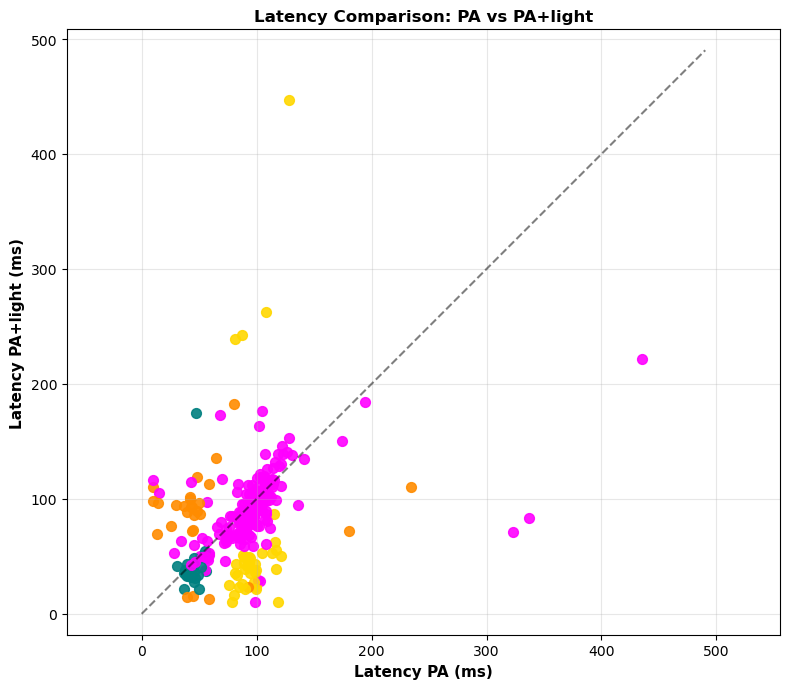

In [95]:
print("\n" + "="*80)
print("GENERATING SUMMARY PLOTS")
print("="*80)

# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light
# ============================================================

RESPONSE_COLORS_PLOT1 = {
    ('inhibitory', 'inhibitory'): 'teal',
    ('inhibitory', 'excitatory'): 'darkorange',
    ('inhibitory', None):         'blue',
    ('excitatory', 'inhibitory'): 'gold',
    ('excitatory', 'excitatory'): 'magenta',
    ('excitatory', None):         'red',
    (None,         'inhibitory'): 'green',
    (None,         'excitatory'): 'purple',
}

plt.figure(figsize=(8, 7))

for dc in sorted(summary_df.index.get_level_values("dc").unique()):
    sub = summary_df.xs(dc, level="dc")   # one row per cluster_id
    if sub.empty:
        continue
    
    for _, r in sub.iterrows():
        resp_pa = r.get("response_type_pa", None)
        resp_pl = r.get("response_type_pl", None)
        resp_pa = resp_pa if isinstance(resp_pa, str) else None
        resp_pl = resp_pl if isinstance(resp_pl, str) else None
        color_base = RESPONSE_COLORS_PLOT1.get((resp_pa, resp_pl), 'grey')

        plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color_base, s=50, alpha=0.9)

# Unity line
max_lat = max(summary_df.latency_ms_pa.max(), summary_df.latency_ms_pl.max())
plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
plt.title("Latency Comparison: PA vs PA+light", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{figure_dir}/all_sessions_summary_latency_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: summary_latency_comparison.png")
plt.show()

In [14]:
summary_df_exc = summary_df.query(
    'response_type_pa == "excitatory" or response_type_pl == "excitatory"'
).copy()
summary_df_inh = summary_df.query(
    'response_type_pa == "inhibitory" or response_type_pl == "inhibitory"'
).copy()

✓ Saved: summary_excitatory_response_rate.png


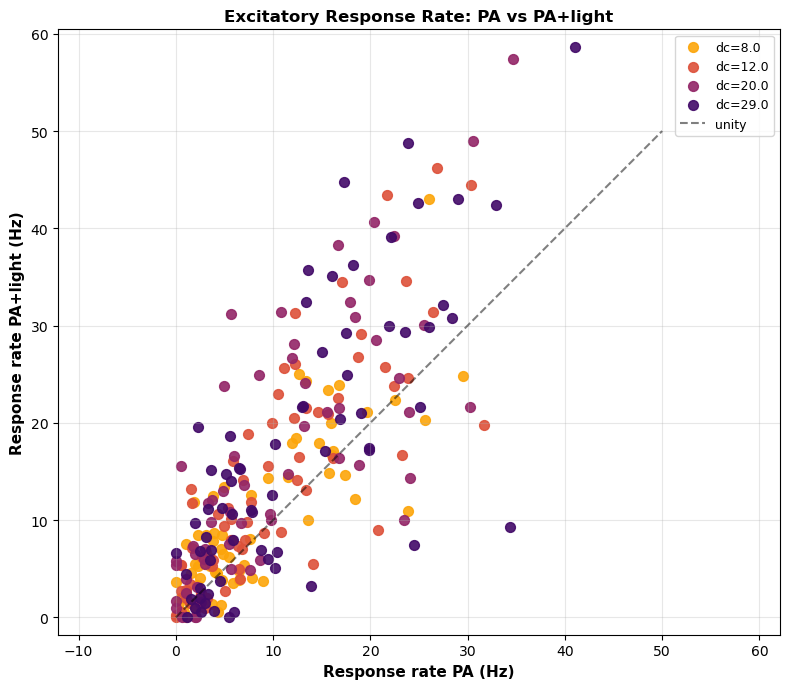

In [16]:
# ============================================================
# SUMMARY PLOT 2: EXCITATORY RESPONSE RATE
# ============================================================

plt.figure(figsize=(8, 7))

if not summary_df_exc.empty:
    for dc in sorted(summary_df_exc.index.get_level_values("dc").unique()):
        sub = summary_df_exc.xs(dc, level="dc")
        if sub.empty:
            continue

        color = color_dc(dc)
        plt.scatter(
            sub.response_rate_pa,
            sub.response_rate_pl,
            color=color, s=50, alpha=0.9, label=f"dc={dc}"
        )

    # Unity line
    # maxv = max(summary_df_exc.response_rate_pa.max(), summary_df_exc.response_rate_pl.max())
    maxv = 50
    
    plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')

    plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
    plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
    plt.title(f"Excitatory Response Rate: PA vs PA+light",
                fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(f'{figure_dir}/Summary_excitatory_response_rate.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: summary_excitatory_response_rate.png")
    plt.show()
else:
    print("No excitatory responses found for comparison plot.")

NameError: name 'df' is not defined

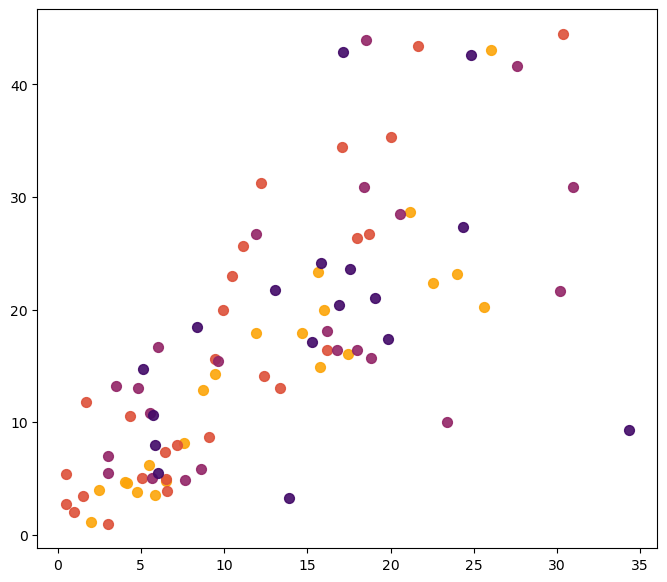

In [17]:
# ============================================================
# SUMMARY PLOT 3: INHIBITORY RESPONSE RATE
# (uses precomputed summary_df_inh)
# ============================================================

plt.figure(figsize=(8, 7))

if not summary_df_inh.empty:
    for dc in sorted(summary_df_inh.index.get_level_values("dc").unique()):
        sub = summary_df_inh.xs(dc, level="dc")
        if sub.empty:
            continue

        color = color_dc(dc)
        plt.scatter(
            sub.response_rate_pa,
            sub.response_rate_pl,
            color=color, s=50, alpha=0.9, label=f"dc={dc}"
        )

    # Unity line
    maxv = df[df.response_type == "inhibitory"].response_rate.max()
    plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')

    plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
    plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
    plt.title(f"Inhibitory Response Rate: PA vs PA+light",
                fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(f'{figure_dir}/{session_id}_summary_inhibitory_response_rate.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: summary_inhibitory_response_rate.png")
    plt.show()
else:
    print("No inhibitory responses found for comparison plot.")

print("\n" + "="*80)
print("SUMMARY PLOTS COMPLETE")
print("="*80)



[251014_A] Processing 85 clusters …

[251014_B] Processing 68 clusters …

[251015] Processing 142 clusters …

✓ Total z-scored PSTHs collected across all sessions: 676

✓ Saved: /media/aleong/Audrey-experiments/combined_figures/zscore_heatmap_all_sessions_combined.png


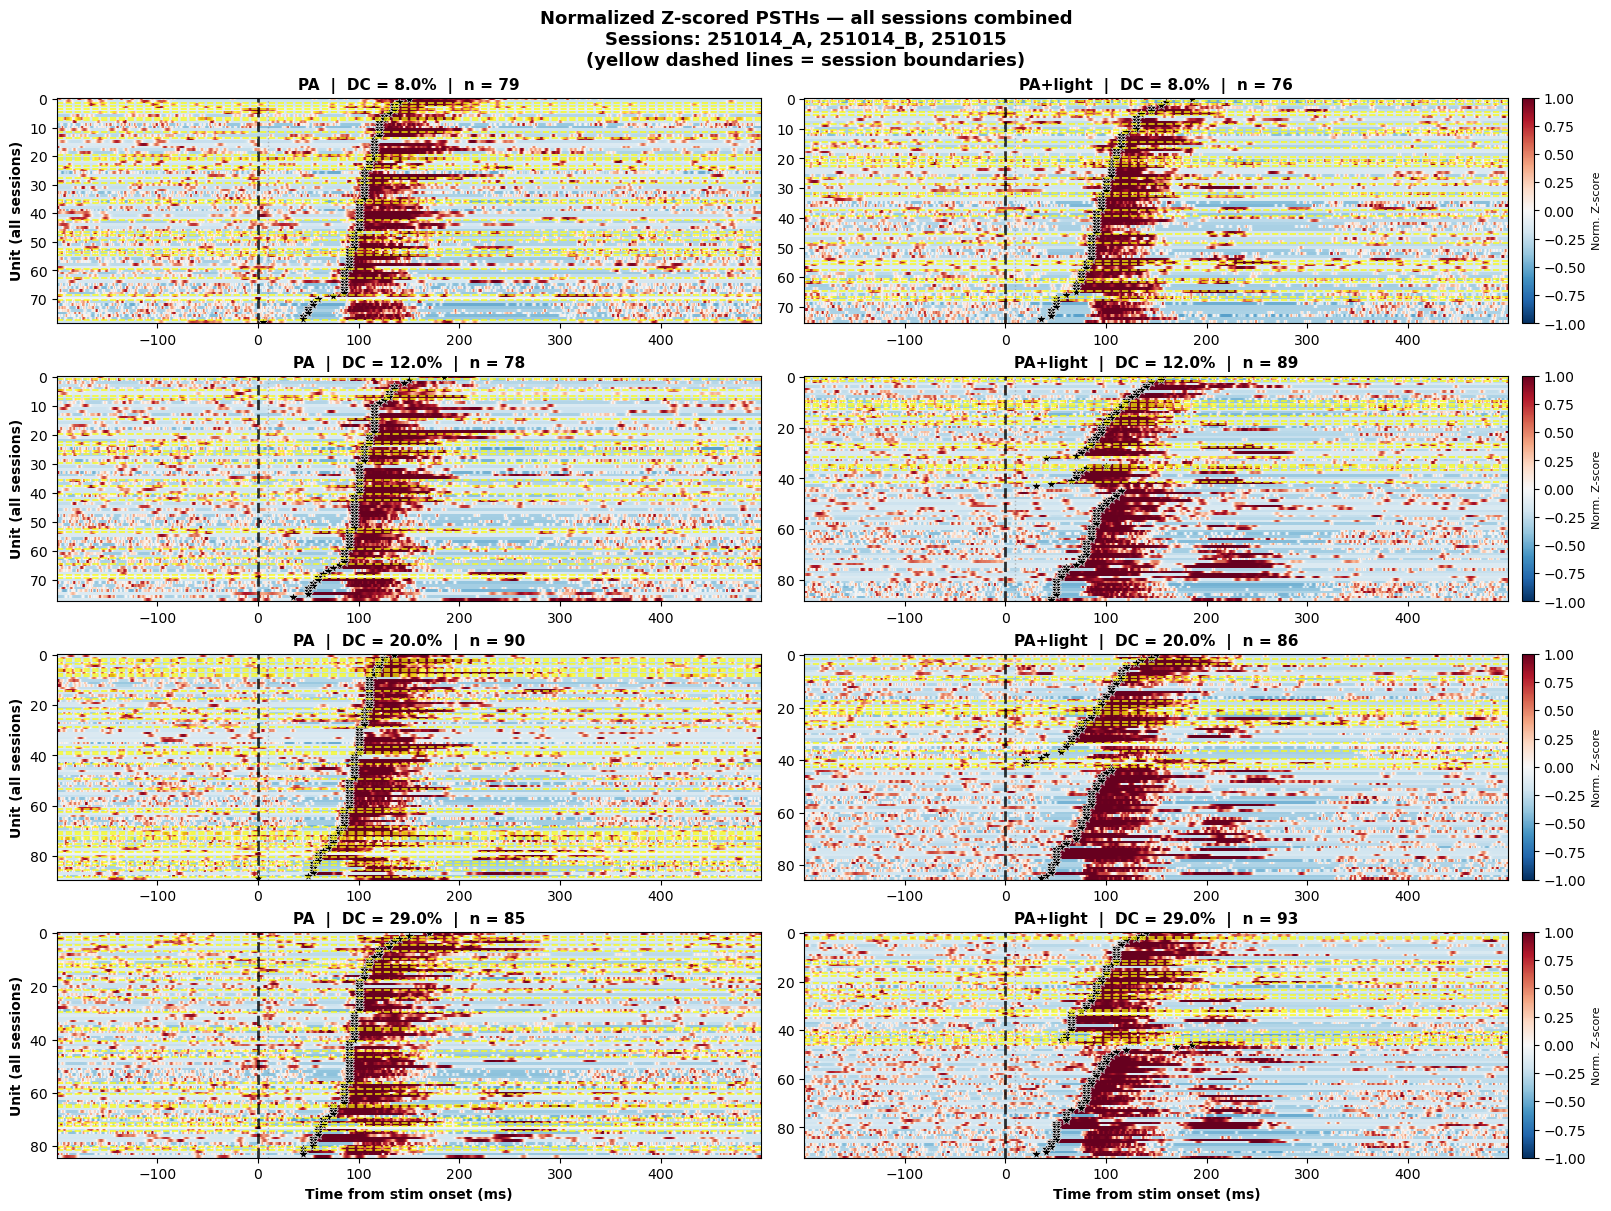


MULTI-SESSION Z-SCORE HEATMAP COMPLETE


In [91]:
# ============================================================
# MULTI-SESSION Z-SCORE HEATMAP
# ============================================================
# This cell computes z-scored PSTHs for ALL sessions combined
# and plots one heatmap per DC (rows), split by PA vs PA+light (cols).
#
# PREREQUISITES (must be run before this cell):
#   - psth_params.py  (provides t_edges, t_centers, BIN_SIZE_MS, PRE_TIME_MS,
#                      MIN_BASELINE_HZ, MIN_LATENCY_MS)
#   - psth_utils.py   (provides get_adaptive_smooth_sd, sort_key)
#   - DataIO class available (from data_io import DataIO)
#   - For each session: a data_io object, pref_ec_dict, selected_rec_names
#     and the corresponding `all_results` list (from the main analysis cell)
#     must already exist.  We therefore collect everything by re-running the
#     z-score loop over each session's own data_io.
#
# HOW TO USE:
#   1. Define `SESSION_CONFIGS` below, one entry per session.
#   2. Each entry must provide:
#        - session_id       : str, e.g. '251015'
#        - data_dir         : Path, pointing to the session's Analysis folder
#        - all_results      : list[dict] produced by the main PSTH analysis cell
#                             (contains cluster_id, train_id, dc, stim, …)
#        - data_io          : DataIO object already loaded for this session
#        - pref_ec_dict     : {cluster_id: preferred_electrode}
#        - selected_rec_names : list of recording names for this session
#   3. Run the cell. It will produce one combined heatmap figure.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import pandas as pd

# ── Import shared params & helpers ───────────────────────────────────────────
# (already imported when running inside the notebook environment)
# from psth_params import *
# from psth_utils import get_adaptive_smooth_sd, sort_key

# ============================================================
# SESSION CONFIGURATION
# ============================================================
# Edit this list to add / remove sessions.
# Each dict must mirror the variables available in a single-session run.

# -------------- 251014_A -------------------------
session_id = '251014_A'
data_dir_251014_A = Path(r'/media/aleong/Audrey-experiments') / session_id / 'Analysis'
data_io_251014_A = DataIO(data_dir_251014_A)
data_io_251014_A.load_session(session_id, load_pickle=False, load_waveforms=False)
data_io_251014_A.dump_as_pickle()
selected_rec_names_251014_A = [rec_id for rec_id in data_io_251014_A.recording_ids
                               if f'_005_' in rec_id or f'_007_' in rec_id]
loadname = data_dir_251014_A / f'{session_id}_cells.csv'
all_results_251014_A = pd.read_csv(loadname, header=[0, 1], index_col=0)

pref_ec_dict_251014_A = {}
for cluster_id in data_io_251014_A.cluster_df.index.values:
    pref_ec = None
    n_sig_pref_ec = None

    max_fr = None
    for ec in data_io_251014_A.burst_df.electrode.unique():
        if pd.isna(ec):
            continue

        df = data_io_251014_A.burst_df.query(f'electrode == {float(ec)}')
        tids = df.train_id.unique()
        n_sig = 0
        for tid in tids:
            if all_results_251014_A.loc[cluster_id, (tid, 'is_significant')] == True:
                n_sig += 1

        if n_sig > 1:
            if pref_ec is None or n_sig > n_sig_pref_ec:
                pref_ec = ec
                n_sig_pref_ec = n_sig

    pref_ec_dict_251014_A[cluster_id] = pref_ec


# -------------- 251014_B -------------------------
session_id = '251014_B'
data_dir_251014_B = Path(r'/media/aleong/Audrey-experiments') / session_id / 'Analysis'
data_io_251014_B = DataIO(data_dir_251014_B)
data_io_251014_B.load_session(session_id, load_pickle=False, load_waveforms=False)
data_io_251014_B.dump_as_pickle()
selected_rec_names_251014_B = [rec_id for rec_id in data_io_251014_B.recording_ids
                               if f'_006_' in rec_id or f'_007_' in rec_id]
loadname = data_dir_251014_B / f'{session_id}_cells.csv'
all_results_251014_B = pd.read_csv(loadname, header=[0, 1], index_col=0)

pref_ec_dict_251014_B = {}
for cluster_id in data_io_251014_B.cluster_df.index.values:
    pref_ec = None
    n_sig_pref_ec = None

    max_fr = None
    for ec in data_io_251014_B.burst_df.electrode.unique():
        if pd.isna(ec):
            continue

        df = data_io_251014_B.burst_df.query(f'electrode == {float(ec)}')
        tids = df.train_id.unique()
        n_sig = 0
        for tid in tids:
            if all_results_251014_B.loc[cluster_id, (tid, 'is_significant')] == True:
                n_sig += 1

        if n_sig > 1:
            if pref_ec is None or n_sig > n_sig_pref_ec:
                pref_ec = ec
                n_sig_pref_ec = n_sig

    pref_ec_dict_251014_B[cluster_id] = pref_ec

# -------------- 251015 -------------------------
session_id = '251015'
data_dir_251015 = Path(r'/media/aleong/Audrey-experiments') / session_id / 'Analysis'
data_io_251015 = DataIO(data_dir_251015)
data_io_251015.load_session(session_id, load_pickle=False, load_waveforms=False)
data_io_251015.dump_as_pickle()
selected_rec_names_251015 = [rec_id for rec_id in data_io_251015.recording_ids
                               if f'_006_' in rec_id or f'_007_' in rec_id]
loadname = data_dir_251015 / f'{session_id}_cells.csv'
all_results_251015 = pd.read_csv(loadname, header=[0, 1], index_col=0)

pref_ec_dict_251015 = {}
for cluster_id in data_io_251015.cluster_df.index.values:
    pref_ec = None
    n_sig_pref_ec = None

    max_fr = None
    for ec in data_io_251015.burst_df.electrode.unique():
        if pd.isna(ec):
            continue

        df = data_io_251015.burst_df.query(f'electrode == {float(ec)}')
        tids = df.train_id.unique()
        n_sig = 0
        for tid in tids:
            if all_results_251015.loc[cluster_id, (tid, 'is_significant')] == True:
                n_sig += 1

        if n_sig > 1:
            if pref_ec is None or n_sig > n_sig_pref_ec:
                pref_ec = ec
                n_sig_pref_ec = n_sig

    pref_ec_dict_251015[cluster_id] = pref_ec


SESSION_CONFIGS = [
    dict(
        session_id        = '251014_A',
        data_dir          = Path(r'/media/aleong/Audrey-experiments/251014_A/Analysis'),
        all_results       = all_results_251014_A,     # ← replace with your variable name
        data_io           = data_io_251014_A,
        pref_ec_dict      = pref_ec_dict_251014_A,
        selected_rec_names= selected_rec_names_251014_A,
    ),
    dict(
        session_id        = '251014_B',
        data_dir          = Path(r'/media/aleong/Audrey-experiments/251014_B/Analysis'),
        all_results       = all_results_251014_B,
        data_io           = data_io_251014_B,
        pref_ec_dict      = pref_ec_dict_251014_B,
        selected_rec_names= selected_rec_names_251014_B,
    ),
    dict(
        session_id        = '251015',
        data_dir          = Path(r'/media/aleong/Audrey-experiments/251015/Analysis'),
        all_results       = all_results_251015,              # ← variable from the current session
        data_io           = data_io_251015,
        pref_ec_dict      = pref_ec_dict_251015,
        selected_rec_names= selected_rec_names_251015,
    ),
]

# Output directory for the combined figure
COMBINED_FIGURE_DIR = Path(r'/media/aleong/Audrey-experiments/combined_figures')
COMBINED_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_DC = 37   # duty-cycle value to skip (set to None to keep all)



[251014_A] Parsing significant responses …
[251014_A] 890 significant (cluster, train_id) pairs found.

[251014_B] Parsing significant responses …
[251014_B] 1142 significant (cluster, train_id) pairs found.

[251015] Parsing significant responses …
[251015] 2078 significant (cluster, train_id) pairs found.

✓ Total z-scored PSTHs collected across all sessions: 676

✓ Saved: /media/aleong/Audrey-experiments/combined_figures/zscore_heatmap_all_sessions_combined.png


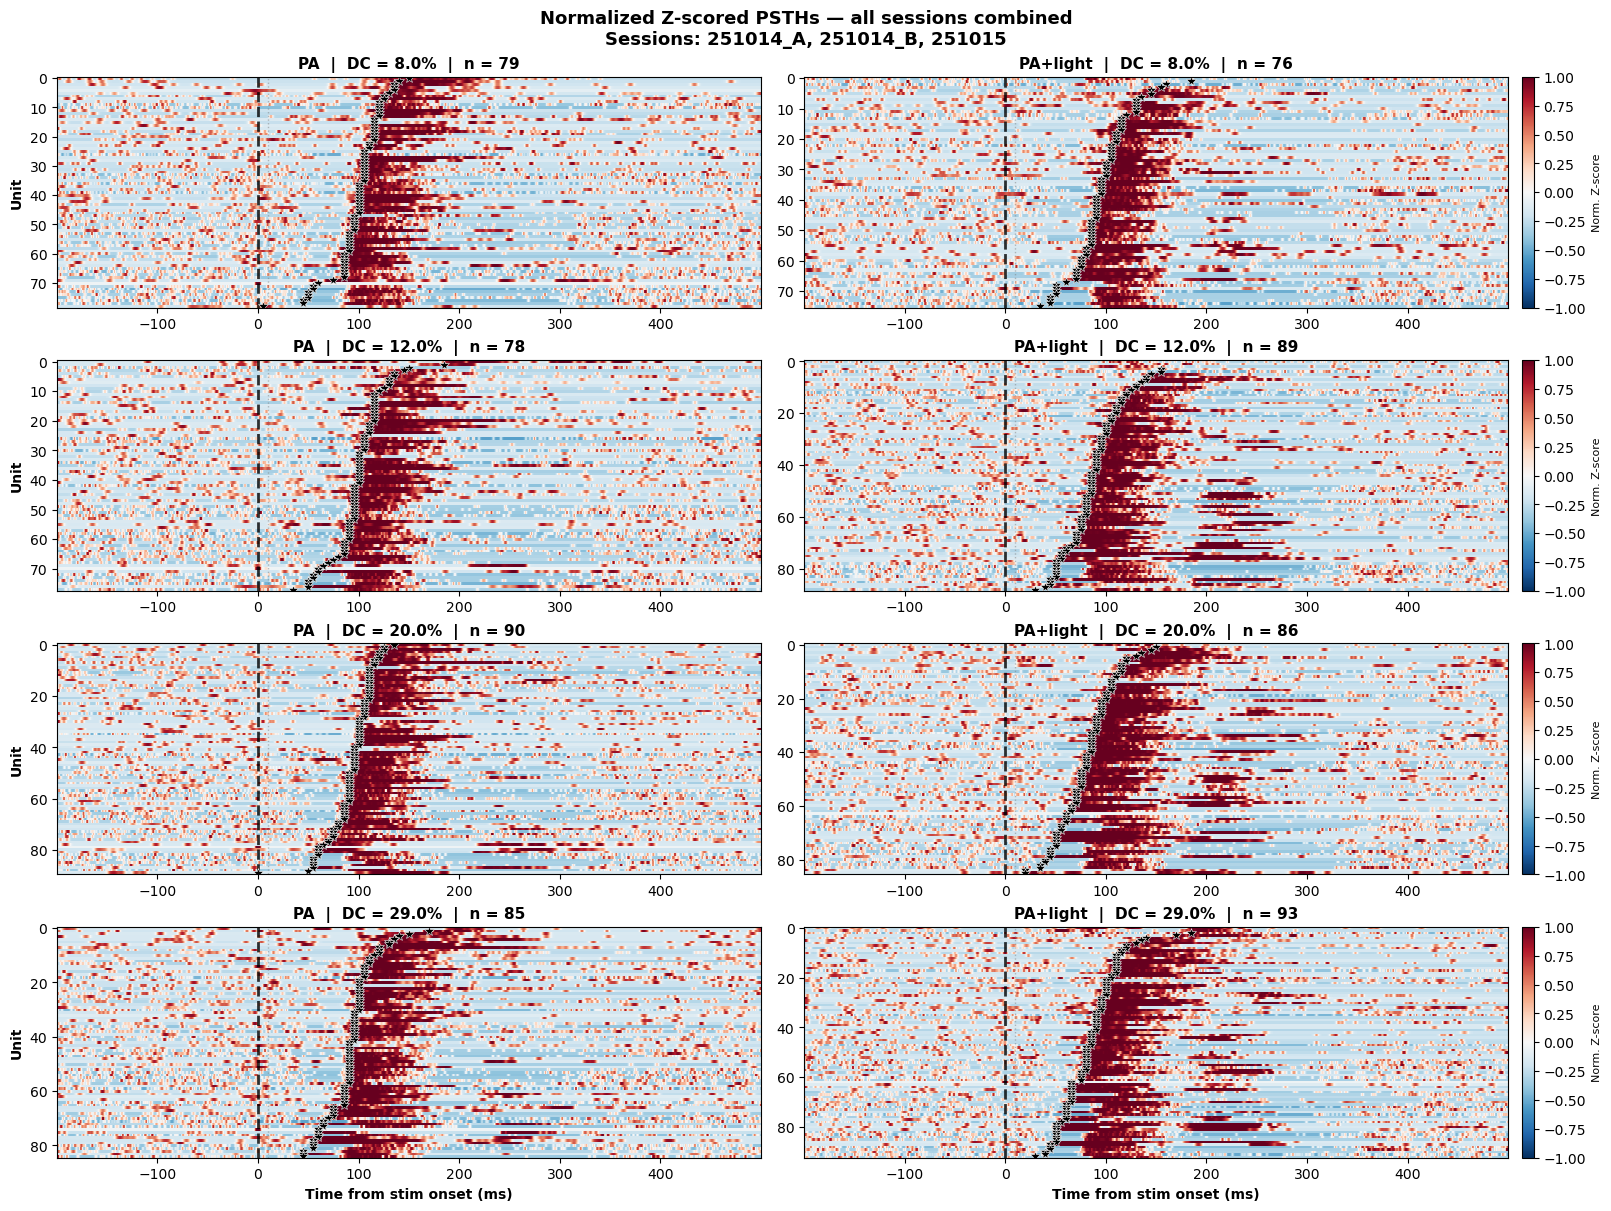


MULTI-SESSION Z-SCORE HEATMAP COMPLETE


In [94]:
# ============================================================
# HELPER — parse any all_results format into a uniform list
# ============================================================
# Every entry in the returned list is a dict with keys:
#   cluster_id, train_id, dc, stim, latency_ms

def _parse_all_results(all_results, data_io, selected_rec_names):
    """
    Convert any of the three all_results formats into a uniform
    list of dicts: {cluster_id, train_id, dc, stim, latency_ms}.

    For cells_df (Format C) dc and stim are not stored directly, so
    we recover them by joining against data_io.burst_df on train_id.
    """

    # ── Format A: list of dicts ───────────────────────────────────────────────
    if isinstance(all_results, list):
        return [
            dict(
                cluster_id = r['cluster_id'],
                train_id   = r['train_id'],
                dc         = r['dc'],
                stim       = r['stim'],
                latency_ms = r.get('latency_ms', np.nan),
            )
            for r in all_results
        ]

    if not isinstance(all_results, pd.DataFrame):
        raise TypeError(f"Unsupported all_results type: {type(all_results)}")

    # ── Format B: flat DataFrame ──────────────────────────────────────────────
    if not isinstance(all_results.columns, pd.MultiIndex):
        records = []
        for _, r in all_results.iterrows():
            records.append(dict(
                cluster_id = r['cluster_id'],
                train_id   = r['train_id'],
                dc         = r['dc'],
                stim       = r['stim'],
                latency_ms = r.get('latency_ms', np.nan),
            ))
        return records

    # ── Format C: cells_df wide MultiIndex DataFrame ──────────────────────────
    # rows = cluster_id, cols = (train_id, metric)
    # We need to recover dc and stim from burst_df.
    bdf = data_io.burst_df.copy()

    # Build a tid → (dc, stim) lookup from burst_df + selected_rec_names
    tid_info = {}
    for rec_name in selected_rec_names:
        if '_light_pa_' in rec_name:
            stim_label = 'PA+light'
            dc_col     = 'laser_duty_cycle'
        elif '_pa_' in rec_name:
            stim_label = 'PA'
            dc_col     = 'duty_cycle'
        else:
            continue

        sub = bdf[bdf['recording_name'] == rec_name]
        for tid, grp in sub.groupby('train_id'):
            dc_val = grp[dc_col].iloc[0]
            tid_info[tid] = dict(stim=stim_label, dc=dc_val)

    tids = all_results.columns.get_level_values(0).unique()
    records = []
    for cluster_id in all_results.index:
        for tid in tids:
            try:
                is_sig = all_results.loc[cluster_id, (tid, 'is_significant')]
            except KeyError:
                continue
            if is_sig is not True and is_sig != True:
                continue
            if tid not in tid_info:
                continue
            try:
                latency = float(all_results.loc[cluster_id, (tid, 'response_latency')])
                if np.isnan(latency):
                    latency = np.nan
            except (KeyError, TypeError, ValueError):
                latency = np.nan

            records.append(dict(
                cluster_id = cluster_id,
                train_id   = tid,
                dc         = tid_info[tid]['dc'],
                stim       = tid_info[tid]['stim'],
                latency_ms = latency,
            ))
    return records


# ============================================================
# STEP 1 — COLLECT Z-SCORED PSTHs FROM ALL SESSIONS
# ============================================================

zscore_data_all = []

for cfg in SESSION_CONFIGS:
    _session_id         = cfg['session_id']
    _data_io            = cfg['data_io']
    _all_results        = cfg['all_results']
    _selected_rec_names = cfg['selected_rec_names']

    print(f"\n[{_session_id}] Parsing significant responses …")
    _records = _parse_all_results(_all_results, _data_io, _selected_rec_names)

    if EXCLUDE_DC is not None:
        _records = [r for r in _records if r['dc'] != EXCLUDE_DC]

    print(f"[{_session_id}] {len(_records)} significant (cluster, train_id) pairs found.")

    _pref_ec_dict = cfg['pref_ec_dict']

    # Build a fast burst_df lookup: train_id → row
    _tid_to_burst = _data_io.burst_df.drop_duplicates('train_id').set_index('train_id')

    for rec in _records:
        cluster_id = rec['cluster_id']

        # ── Preferred-electrode gate ──────────────────────────────────────────
        # Only keep responses at the cluster's preferred electrode.
        pref_ec = _pref_ec_dict.get(cluster_id)
        if pref_ec is None:
            continue
        try:
            train_ec = _tid_to_burst.loc[rec['train_id'], 'electrode']
            if train_ec != pref_ec:
                continue
        except KeyError:
            continue
        tid        = rec['train_id']
        stim       = rec['stim']
        dc         = rec['dc']
        latency    = rec['latency_ms']

        try:
            burst_row = _tid_to_burst.loc[tid]
        except KeyError:
            continue

        rec_id   = str(burst_row['rec_id'])
        stimtype = str(burst_row['stimtype'])

        # Get burst onsets
        burst_rows = _data_io.burst_df[_data_io.burst_df['train_id'] == tid]
        if stimtype in ('laser', 'padmd'):
            burst_onsets = burst_rows['laser_burst_onset'].values
        elif stimtype == 'dmd':
            burst_onsets = burst_rows['dmd_burst_onset'].values
        else:
            continue

        # Get spike train
        try:
            spiketrain = _data_io.spiketimes[rec_id][cluster_id]
        except KeyError:
            continue

        # Build PSTH
        binned = []
        for onset in burst_onsets:
            idx = np.where(
                (spiketrain >= onset + t_edges[0]) &
                (spiketrain <  onset + t_edges[-1])
            )[0]
            rel = spiketrain[idx] - onset
            counts, _ = np.histogram(rel, bins=t_edges)
            binned.append(counts)

        if len(binned) == 0:
            continue

        binned = np.vstack(binned)
        rate   = binned.sum(axis=0) / (len(binned) * (BIN_SIZE_MS / 1000.0))

        # Baseline statistics
        baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
        baseline_rate = rate[baseline_mask].mean()
        if baseline_rate < MIN_BASELINE_HZ:
            continue

        # Adaptive smoothing + z-score
        smooth_sd   = get_adaptive_smooth_sd(baseline_rate)
        rate_smooth = gaussian_filter1d(rate, smooth_sd)
        mu          = rate_smooth[baseline_mask].mean()
        sd          = rate_smooth[baseline_mask].std(ddof=1)

        zscore      = (rate_smooth - mu) / sd if sd > 0 else np.zeros_like(rate_smooth)
        zscore_norm = np.tanh(zscore / 3)   # compress to [-1, 1]

        zscore_data_all.append({
            'session_id' : _session_id,
            'cluster_id' : cluster_id,
            'stim'       : stim,
            'dc'         : dc,
            'train_id'   : tid,
            'latency'    : latency,
            'zscore'     : zscore_norm,
            'zscore_raw' : zscore,
            'rate'       : rate_smooth,
        })

print(f"\n✓ Total z-scored PSTHs collected across all sessions: {len(zscore_data_all)}")


# ============================================================
# STEP 2 — PLOT COMBINED HEATMAPS
# rows = DC values, cols = [PA, PA+light]
# ============================================================

all_dcs = sorted(set(e['dc'] for e in zscore_data_all))

n_dc = len(all_dcs)

if n_dc == 0:
    print("No duty-cycle values found — nothing to plot.")
else:
    fig, axes = plt.subplots(
        n_dc, 2,
        figsize=(16, 3 * n_dc),
        constrained_layout=True,
    )
    if n_dc == 1:
        axes = axes.reshape(1, -1)

    def _sort_key(entry):
        """Sort: excitatory first, then by latency descending (slowest at top)."""
        resp_type  = entry.get('response_type', 'unknown')
        latency    = entry.get('latency', 999)
        if isinstance(latency, float) and np.isnan(latency):
            latency = 999
        type_order = 0 if resp_type == 'excitatory' else 1
        return (type_order, -latency)

    for row_i, dc in enumerate(all_dcs):
        for col_i, stim in enumerate(['PA', 'PA+light']):

            ax = axes[row_i, col_i]
            subset = [e for e in zscore_data_all if e['dc'] == dc and e['stim'] == stim]

            if len(subset) == 0:
                ax.text(0.5, 0.5, f'No data\nDC={dc}%\n{stim}',
                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
                ax.set_title(f'{stim} | DC={dc}%', fontweight='bold')
                ax.axis('off')
                continue

            subset_sorted = sorted(subset, key=_sort_key)
            n_units = len(subset_sorted)

            hm = np.vstack([e['zscore'] for e in subset_sorted])

            im = ax.imshow(
                hm,
                aspect='auto',
                cmap='RdBu_r',
                vmin=-1, vmax=1,
                interpolation='nearest',
                extent=[t_centers[0], t_centers[-1], n_units - 0.5, -0.5],
            )

            # Stimulus onset & detection-start lines
            ax.axvline(0,              color='black', linewidth=2,  linestyle='--', alpha=0.8)
            ax.axvline(MIN_LATENCY_MS, color='gray',  linewidth=1,  linestyle=':',  alpha=0.5)

            # Latency markers
            for unit_i, entry in enumerate(subset_sorted):
                lat = entry.get('latency', np.nan)
                if isinstance(lat, float) and not np.isnan(lat):
                    ax.plot(lat, unit_i, 'k*', markersize=7,
                            markeredgecolor='white', markeredgewidth=0.4)

            if col_i == 1:
                cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
                cbar.set_label('Norm. Z-score', fontsize=8)

            if row_i == n_dc - 1:
                ax.set_xlabel('Time from stim onset (ms)', fontsize=10, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel('Unit', fontsize=10, fontweight='bold')

            ax.set_title(f'{stim}  |  DC = {dc}%  |  n = {n_units}',
                         fontsize=11, fontweight='bold')

    session_labels = ', '.join(cfg['session_id'] for cfg in SESSION_CONFIGS)
    plt.suptitle(
        f'Normalized Z-scored PSTHs — all sessions combined\n'
        f'Sessions: {session_labels}',
        fontsize=13, fontweight='bold',
    )

    save_path = COMBINED_FIGURE_DIR / 'zscore_heatmap_all_sessions_combined.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'\n✓ Saved: {save_path}')
    plt.show()

print('\n' + '=' * 80)
print('MULTI-SESSION Z-SCORE HEATMAP COMPLETE')
print('=' * 80)

In [90]:
_all_results.to_csv(data_dir / 'all_results.csv')

# Merging with the cell typing data

In [10]:
def extract_cell_type(cell_type_value):
    """
    Extract ON / OFF / ON-OFF from a cell_type dict or string.

    Handles:
      - dict with a 'name' key  → e.g. {'id': 3, 'name': 'OFF suppression 2'}
      - plain string             → e.g. 'ON sustained'
      - None / NaN               → returns None
    """

    if cell_type_value is None:
        return None
    # Unwrap dict
    if isinstance(cell_type_value, dict):
        name = cell_type_value.get('name', '')
    elif isinstance(cell_type_value, str):
        name = cell_type_value
    else:
        return None   # unexpected type (float NaN, etc.)

    name_upper = name.upper()
    # Check ON-OFF first so it isn't caught by the bare ON / OFF checks
    if 'ON-OFF' in name_upper or 'ON/OFF' in name_upper:
        return 'ON-OFF'
    elif 'OFF' in name_upper:
        return 'OFF'
    elif "'ON" in name_upper:
        return 'ON'
    return None


GENERATING SUMMARY PLOTS (with cell typing)
✓ Saved: all_sessions_summary_latency_comparison.png


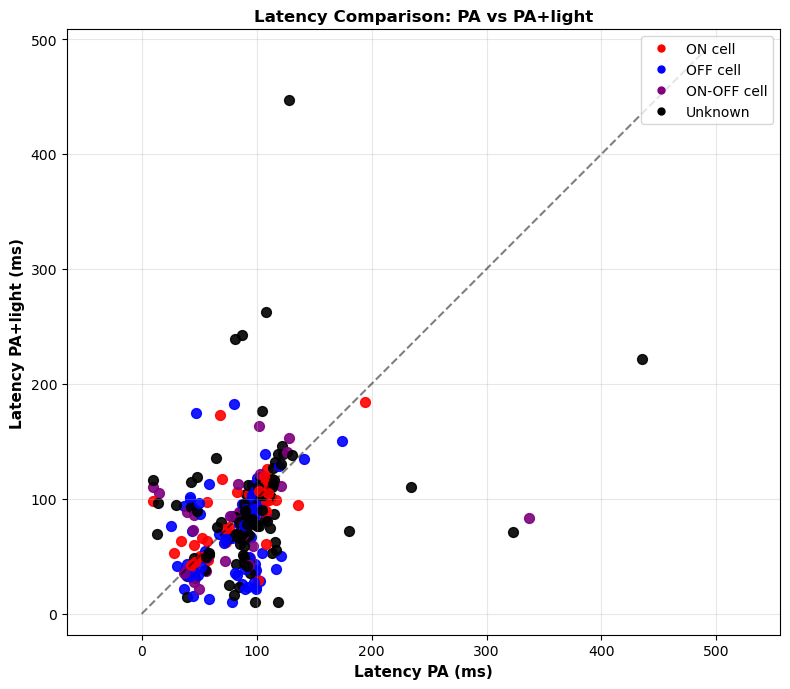

In [11]:
print("\n" + "="*80)
print("GENERATING SUMMARY PLOTS (with cell typing)")
print("="*80)

TYPE_COLORS = {
    'ON':     'red',
    'OFF':    'blue',
    'ON-OFF': 'purple',
}

# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light  (with badge_type)
# (uses precomputed summary_df)
# ============================================================

plt.figure(figsize=(8, 7))



for dc in sorted(summary_df.index.get_level_values("dc").unique()):
    sub = summary_df.xs(dc, level="dc")
    if sub.empty:
        continue

    for _, r in sub.iterrows():
        # if isinstance(r.get("baden_type_pa"), dict):
        #     name = r["baden_type_pa"]["name"]
        # elif isinstance(r.get("baden_type_pl"), dict):
        #     name = r["baden_type_pl"]["name"]
        # else:
        #     name = ""
        

        baden_type = r.get('baden_type', None)
        # print(baden_type)
        cell_type  = extract_cell_type(baden_type)
        color_base = TYPE_COLORS.get(cell_type, 'black')

        plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color_base, s=50, alpha=0.9)

legend_elements = [Line2D([0], [0], marker='o', color='red', 
                          label='ON cell',
                          markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='blue', 
                          label='OFF cell',
                          markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='purple',
                          label='ON-OFF cell',
                          markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='black',
                          label='Unknown',
                          markersize=5,
                          linestyle='None'),]

# Unity line
if len(summary_df) > 0:
    max_lat = max(summary_df.latency_ms_pa.max(), summary_df.latency_ms_pl.max())
    plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
plt.title("Latency Comparison: PA vs PA+light", fontsize=12, fontweight='bold')
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{figure_dir}/all_sessions_summary_latency_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: all_sessions_summary_latency_comparison.png")
plt.show()


GENERATING SUMMARY PLOTS (with cell typing)
✓ Saved: all_sessions_summary_latency_comparison.png


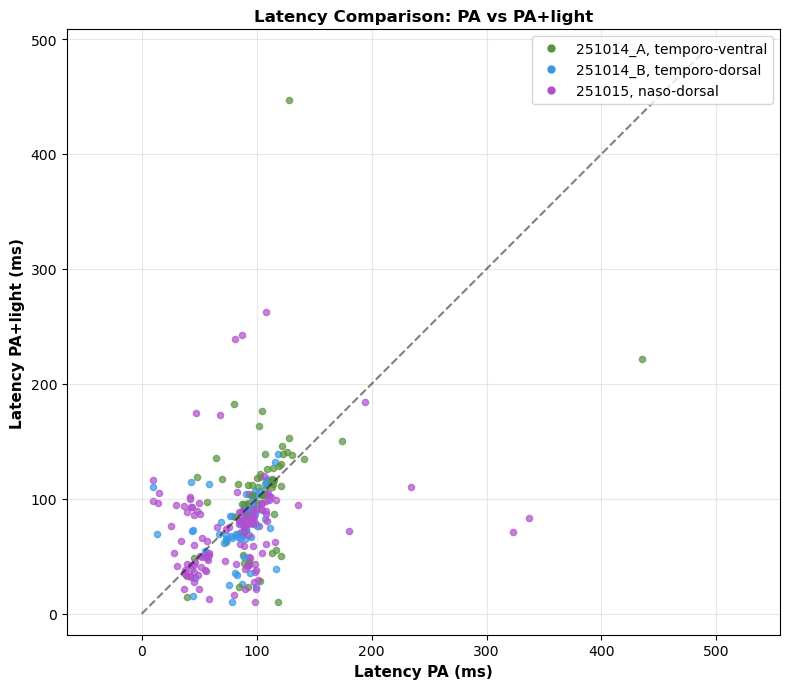

In [120]:
import matplotlib.patches as mpatches

print("\n" + "="*80)
print("GENERATING SUMMARY PLOTS (with cell typing)")
print("="*80)

SESSION_COLORS = {
    '251014_A': "#58943D",
    '251014_B': "#3998E6",
    '251015'  : "#B050CE",
}

RETINA_PART = {
    '251014_A': "TV",
    '251014_B': "TD",
    '251015'  : "ND",
}

# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light  (with badge_type)
# (uses precomputed summary_df)
# ============================================================

plt.figure(figsize=(8, 7))



for dc in sorted(summary_df.index.get_level_values("dc").unique()):
    sub = summary_df.xs(dc, level="dc")
    if sub.empty:
        continue

    for _, r in sub.iterrows():
        # if isinstance(r.get("baden_type_pa"), dict):
        #     name = r["baden_type_pa"]["name"]
        # elif isinstance(r.get("baden_type_pl"), dict):
        #     name = r["baden_type_pl"]["name"]
        # else:
        #     name = ""
        

        # baden_type = r.session
        # # print(baden_type)
        # cell_type  = extract_cell_type(baden_type)
        # if cell_type is None:
        #     print("None")
        # color_base = TYPE_COLORS.get(cell_type, 'black')

        color_base = SESSION_COLORS.get(r.session, 'black')
        retina_part = RETINA_PART.get(r.session)

        plt.scatter(r.latency_ms_pa, 
                    r.latency_ms_pl, 
                    color=color_base, 
                    s=20, 
                    alpha=0.7,
                    #label=f"{r.session}, {retina_part}"
        )

legend_elements = [Line2D([0], [0], marker='o', color='#58943D', 
                          label='251014_A, temporo-ventral',
                          markerfacecolor='#58943D', markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='#3998E6', 
                          label='251014_B, temporo-dorsal',
                          markerfacecolor='#3998E6', markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='#B050CE',
                          label='251015, naso-dorsal',
                          markerfacecolor='#B050CE', markersize=5,
                          linestyle='None'),]

# Unity line
if len(summary_df) > 0:
    max_lat = max(summary_df.latency_ms_pa.max(), summary_df.latency_ms_pl.max())
    plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
plt.title("Latency Comparison: PA vs PA+light", fontsize=12, fontweight='bold')
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{figure_dir}/all_sessions_summary_latency_comparison_per_session.png', dpi=150, bbox_inches='tight')
print("✓ Saved: all_sessions_summary_latency_comparison.png")
plt.show()


GENERATING SUMMARY PLOTS (with cell typing)
{'ID': 23, 'NAME': 'ON ALPHA'} True
	ON
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': 3, 'NAME': 'OFF SLOW'} False
	OFF
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
None
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
None
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
None
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
None
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
None
{'ID': NONE, 'NAME': 'NOT ASS

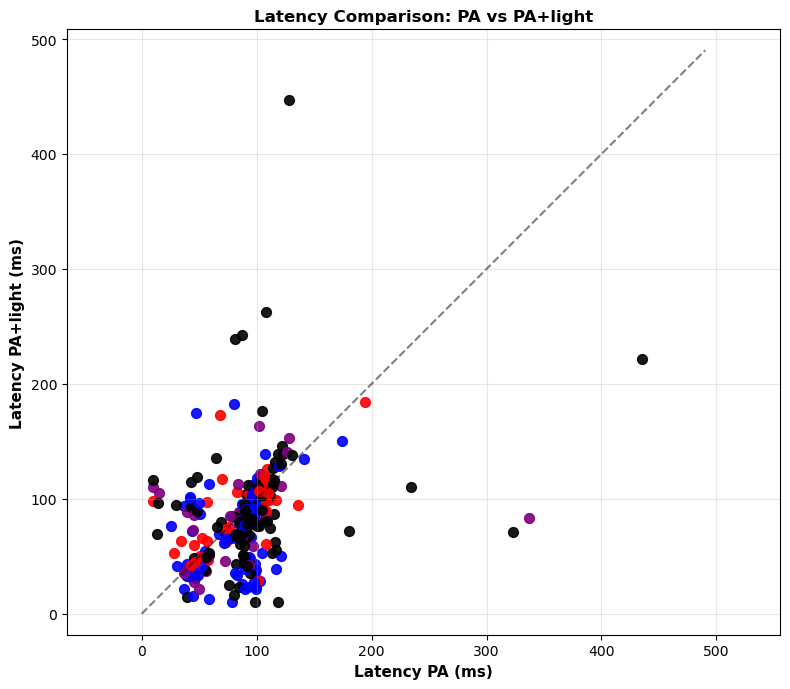

In [ ]:
print("\n" + "="*80)
print("GENERATING SUMMARY PLOTS (with cell typing)")
print("="*80)

TYPE_COLORS = {
    'ON':     'red',
    'OFF':    'blue',
    'ON-OFF': 'purple',
    'Not assigned': 'green',
}

# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light  (with badge_type)
# (uses precomputed summary_df)
# ============================================================

plt.figure(figsize=(8, 7))



for dc in sorted(summary_df.index.get_level_values("dc").unique()):
    sub = summary_df.xs(dc, level="dc")
    if sub.empty:
        continue

    for _, r in sub.iterrows():
        # if isinstance(r.get("baden_type_pa"), dict):
        #     name = r["baden_type_pa"]["name"]
        # elif isinstance(r.get("baden_type_pl"), dict):
        #     name = r["baden_type_pl"]["name"]
        # else:
        #     name = ""
        

        baden_type = r.get('baden_type', None)
        # print(baden_type)
        cell_type  = extract_cell_type(baden_type)
        if cell_type is None:
            print("None")
        color_base = TYPE_COLORS.get(cell_type, 'black')

        plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color_base, s=50, alpha=0.9)

# Unity line
if len(summary_df) > 0:
    max_lat = max(summary_df.latency_ms_pa.max(), summary_df.latency_ms_pl.max())
    plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
plt.title("Latency Comparison: PA vs PA+light", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{figure_dir}/all_sessions_summary_latency_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: all_sessions_summary_latency_comparison.png")
plt.show()

✓ Saved: summary_latency_comparison.png


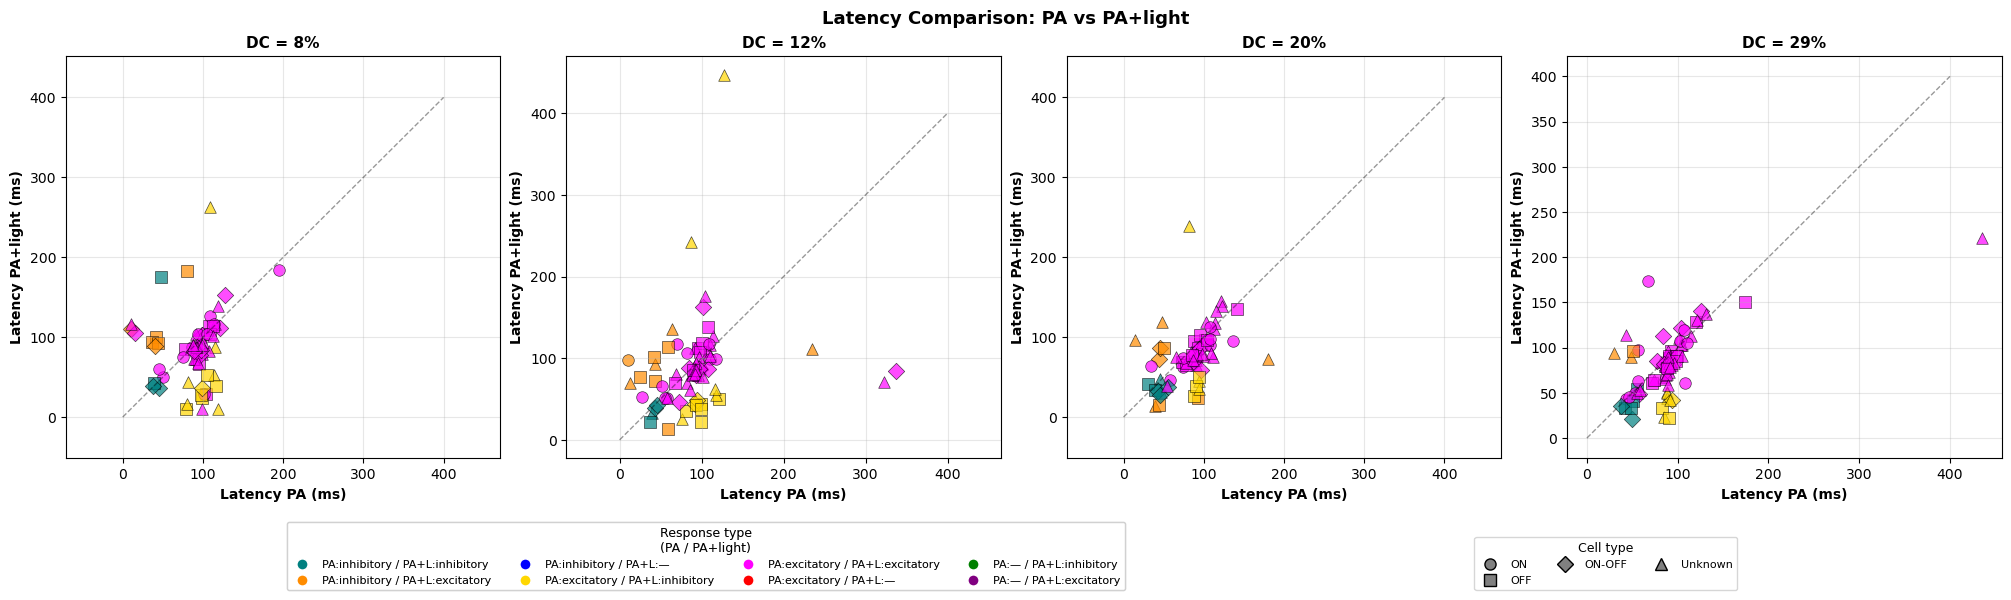

In [66]:
# ── Color encodes PA / PA+light response type combination ──────────────────
# ── Marker encodes cell type (ON / OFF) ────────────────────────────────────
import ast
import numpy as np

RESPONSE_COLORS = {
    ('inhibitory', 'inhibitory'): 'teal',
    ('inhibitory', 'excitatory'): 'darkorange',
    ('inhibitory', None):         'blue',
    ('excitatory', 'inhibitory'): 'gold',
    ('excitatory', 'excitatory'): 'magenta',
    ('excitatory', None):         'red',
    (None,         'inhibitory'): 'green',
    (None,         'excitatory'): 'purple',
}

CELL_TYPE_MARKER = {
    'ON':     'o',   # circle
    'OFF':    's',   # square
    'ON-OFF': 'D',   # diamond
}
CELL_TYPE_MARKER_DEFAULT = '^'   # triangle = unknown / not classified

def _parse_badge(raw):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None
    if isinstance(raw, dict):
        return raw.get('name', '')
    if isinstance(raw, str):
        stripped = raw.strip()
        if stripped.startswith('{'):
            try:
                d = ast.literal_eval(stripped)
                return d.get('name', stripped)
            except Exception:
                pass
        return stripped
    return str(raw)

def extract_cell_type_local(raw):
    name = _parse_badge(raw)
    if name is None:
        return None
    name_upper = name.upper()
    if 'NOT ASSIGNED' in name_upper:
        return None
    if 'ON-OFF' in name_upper or 'ON/OFF' in name_upper:
        return 'ON-OFF'
    if name_upper.startswith('ON'):
        return 'ON'
    if name_upper.startswith('OFF'):
        return 'OFF'
    return None

# ── Filter and sort DCs (drop 37) ─────────────────────────────────────────
dcs = sorted([dc for dc in summary_df.index.get_level_values('dc').unique() if dc != 37])
n_dc = len(dcs)

fig, axes = plt.subplots(
    1, n_dc,
    figsize=(5 * n_dc, 5),
    sharex=False, sharey=False,
    constrained_layout=True,
)

if n_dc == 1:
    axes = [axes]

max_lat = 400

for ax, dc in zip(axes, dcs):
    # ── Filter summary_df to rows for this DC only ─────────────────────────
    dc_sub = summary_df.xs(dc, level='dc')   # index is now just cluster_id

    for _, r in dc_sub.iterrows():

        resp_pa = r.get('response_type_pa', None)
        resp_pl = r.get('response_type_pl', None)
        resp_pa = resp_pa if isinstance(resp_pa, str) else None
        resp_pl = resp_pl if isinstance(resp_pl, str) else None
        color = RESPONSE_COLORS.get((resp_pa, resp_pl), 'grey')

        cell_type = extract_cell_type_local(r.get('baden_type', None))
        marker = CELL_TYPE_MARKER.get(cell_type, CELL_TYPE_MARKER_DEFAULT)

        ax.scatter(
            r.latency_ms_pa, r.latency_ms_pl,
            color=color, marker=marker,
            s=70, alpha=0.7, linewidths=0.5, edgecolors='k',
        )

    ax.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.4, lw=1, label='unity')
    ax.set_xlabel("Latency PA (ms)", fontsize=10, fontweight='bold')
    ax.set_ylabel("Latency PA+light (ms)", fontsize=10, fontweight='bold')
    ax.set_title(f"DC = {dc:.0f}%", fontsize=11, fontweight='bold')
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(alpha=0.3)

# ── Legends ────────────────────────────────────────────────────────────────
color_legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markersize=8, label=f"PA:{pa or '—'} / PA+L:{pl or '—'}")
    for (pa, pl), color in RESPONSE_COLORS.items()
]

marker_legend_handles = [
    plt.Line2D([0], [0], marker=mk, color='w', markerfacecolor='grey',
               markeredgecolor='k', markersize=8, label=f"{ct}")
    for ct, mk in CELL_TYPE_MARKER.items()
] + [
    plt.Line2D([0], [0], marker=CELL_TYPE_MARKER_DEFAULT, color='w',
               markerfacecolor='grey', markeredgecolor='k',
               markersize=8, label='Unknown')
]

leg1 = fig.legend(
    handles=color_legend_handles,
    title='Response type\n(PA / PA+light)',
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.35, -0.18),
    fontsize=8,
    title_fontsize=9,
    framealpha=0.8,
)
leg2 = fig.legend(
    handles=marker_legend_handles,
    title='Cell type',
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.80, -0.18),
    fontsize=8,
    title_fontsize=9,
    framealpha=0.8,
)
fig.add_artist(leg1)

fig.suptitle("Latency Comparison: PA vs PA+light", fontsize=13, fontweight='bold')

plt.savefig(
    f'{figure_dir}/all_sessions_summary_latency_comparison.png',
    dpi=150, bbox_inches='tight',
)
print("✓ Saved: summary_latency_comparison.png")
plt.show()


──── PA response counts (per cell) ────
resp_pa    Excitatory  Inhibitory  No response
cell_type                                     
ON                 24           0            2
OFF                24           6            5
ON-OFF             20           2            3
Unknown            56           1           10

──── PA+light response counts (per cell) ────
resp_pl    Excitatory  Inhibitory  No response
cell_type                                     
ON                 20           0            6
OFF                24           3            8
ON-OFF             18           4            3
Unknown            59           2            6

✓ Saved: response_counts_by_cell_type.png


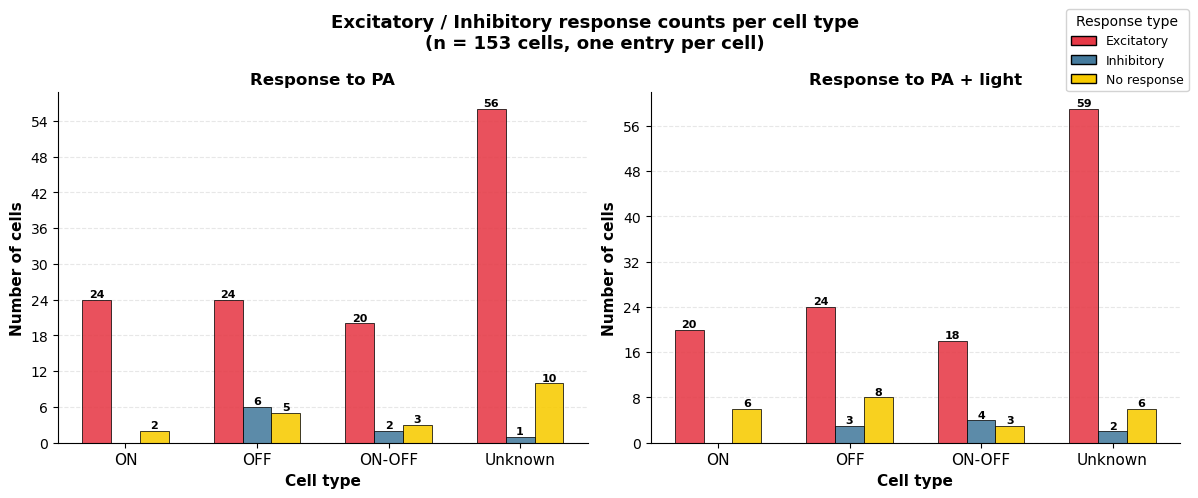

In [12]:
# ============================================================
# RESPONSE TYPE COUNT: ON / OFF / ON-OFF  ×  PA / PA+light
# ============================================================
# Uses summary_df (one row per cluster_id × dc) built in cell 19.
# extract_cell_type(baden_type) must be defined (see cell 21).

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── 1. Build a per-cell (cluster-level) summary ─────────────────────────────
#    For each cluster we take the *most common* response type across DCs,
#    so that every cell contributes exactly once per condition.

def majority_response(series):
    """Return the most frequent non-null value, or None."""
    vals = series.dropna()
    vals = [v for v in vals if isinstance(v, str)]
    if not vals:
        return None
    return pd.Series(vals).mode()[0]

# Reset index so cluster_id is a column
df_cells = (
    summary_df.reset_index()
    .groupby("cluster_id")
    .agg(
        response_type_pa=("response_type_pa", majority_response),
        response_type_pl=("response_type_pl", majority_response),
        baden_type=("baden_type", "first"),
    )
    .reset_index()
)

# ── 2. Classify each cell as ON / OFF / ON-OFF / Unknown ───────────────────
df_cells["cell_type"] = df_cells["baden_type"].apply(
    lambda bt: extract_cell_type(bt) or "Unknown"
)

# ── 3. Normalise response labels (None → "No response") ────────────────────
def norm_resp(v):
    if not isinstance(v, str):
        return "No response"
    return v.capitalize()   # 'excitatory' → 'Excitatory', etc.

df_cells["resp_pa"] = df_cells["response_type_pa"].apply(norm_resp)
df_cells["resp_pl"] = df_cells["response_type_pl"].apply(norm_resp)

# ── 4. Pivot counts ─────────────────────────────────────────────────────────
CELL_TYPES  = ["ON", "OFF", "ON-OFF", "Unknown"]
RESP_LABELS = ["Excitatory", "Inhibitory", "No response"]

def count_table(resp_col):
    """Return DataFrame[cell_type × response_type] with counts."""
    ct = (
        df_cells.groupby(["cell_type", resp_col])
        .size()
        .unstack(fill_value=0)
        .reindex(index=CELL_TYPES, columns=RESP_LABELS, fill_value=0)
    )
    return ct

counts_pa = count_table("resp_pa")
counts_pl = count_table("resp_pl")

print("──── PA response counts (per cell) ────")
print(counts_pa)
print()
print("──── PA+light response counts (per cell) ────")
print(counts_pl)

# ── 5. Grouped bar chart ────────────────────────────────────────────────────
RESP_COLORS = {
    "Excitatory":  "#E63946",   # red-ish
    "Inhibitory":  "#457B9D",   # teal-blue
    "No response": "#F8CB00",   # yellow
}

cell_type_order = [ct for ct in CELL_TYPES if ct in df_cells["cell_type"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (counts, title, stim_label) in zip(
    axes,
    [
        (counts_pa, "Response to PA",        "PA"),
        (counts_pl, "Response to PA + light", "PA + light"),
    ]
):
    n_ct   = len(cell_type_order)
    n_resp = len(RESP_LABELS)
    x      = np.arange(n_ct)
    width  = 0.22
    offsets = np.linspace(-(n_resp - 1) / 2, (n_resp - 1) / 2, n_resp) * width

    for resp, offset in zip(RESP_LABELS, offsets):
        heights = [counts.loc[ct, resp] if ct in counts.index else 0
                   for ct in cell_type_order]
        bars = ax.bar(
            x + offset, heights, width,
            label=resp,
            color=RESP_COLORS[resp],
            edgecolor="k",
            linewidth=0.6,
            alpha=0.88,
        )
        # Annotate non-zero bars
        for bar, h in zip(bars, heights):
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.05,
                    str(int(h)),
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold",
                )

    ax.set_xticks(x)
    ax.set_xticklabels(cell_type_order, fontsize=11)
    ax.set_xlabel("Cell type", fontsize=11, fontweight="bold")
    ax.set_ylabel("Number of cells", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend
handles = [
    mpatches.Patch(facecolor=RESP_COLORS[r], edgecolor="k", label=r)
    for r in RESP_LABELS
]
fig.legend(
    handles=handles,
    title="Response type",
    loc="upper right",
    bbox_to_anchor=(1, 1),
    fontsize=9,
    title_fontsize=10,
    framealpha=0.85,
)

fig.suptitle(
    f"Excitatory / Inhibitory response counts per cell type\n"
    f"(n = {len(df_cells)} cells, one entry per cell)",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()

plt.savefig(
    f"{figure_dir}/{session_id}_response_counts_by_cell_type.png",
    dpi=150, bbox_inches="tight",
)
print("\n✓ Saved: response_counts_by_cell_type.png")
plt.show()


{'ID': 23, 'NAME': 'ON ALPHA'} True
	ON
{'ID': 3, 'NAME': 'OFF SLOW'} False
	OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
{'ID': 2, 'NAME': 'OFF STEP'} False
	OFF
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assigned
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': 9, 'NAME': 'ON-OFF LOCAL-EDGE W3'} True
	ON-OFF
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': 10, 'NAME': 'ON-OFF LOCAL'} True
	ON-OFF
{'ID': 31, 'NAME': 'OFF SUPPRESSION 2'} True
	OFF
{'ID': NONE, 'NAME': 'NOT ASSIGNED'} True
-------------- Not assi

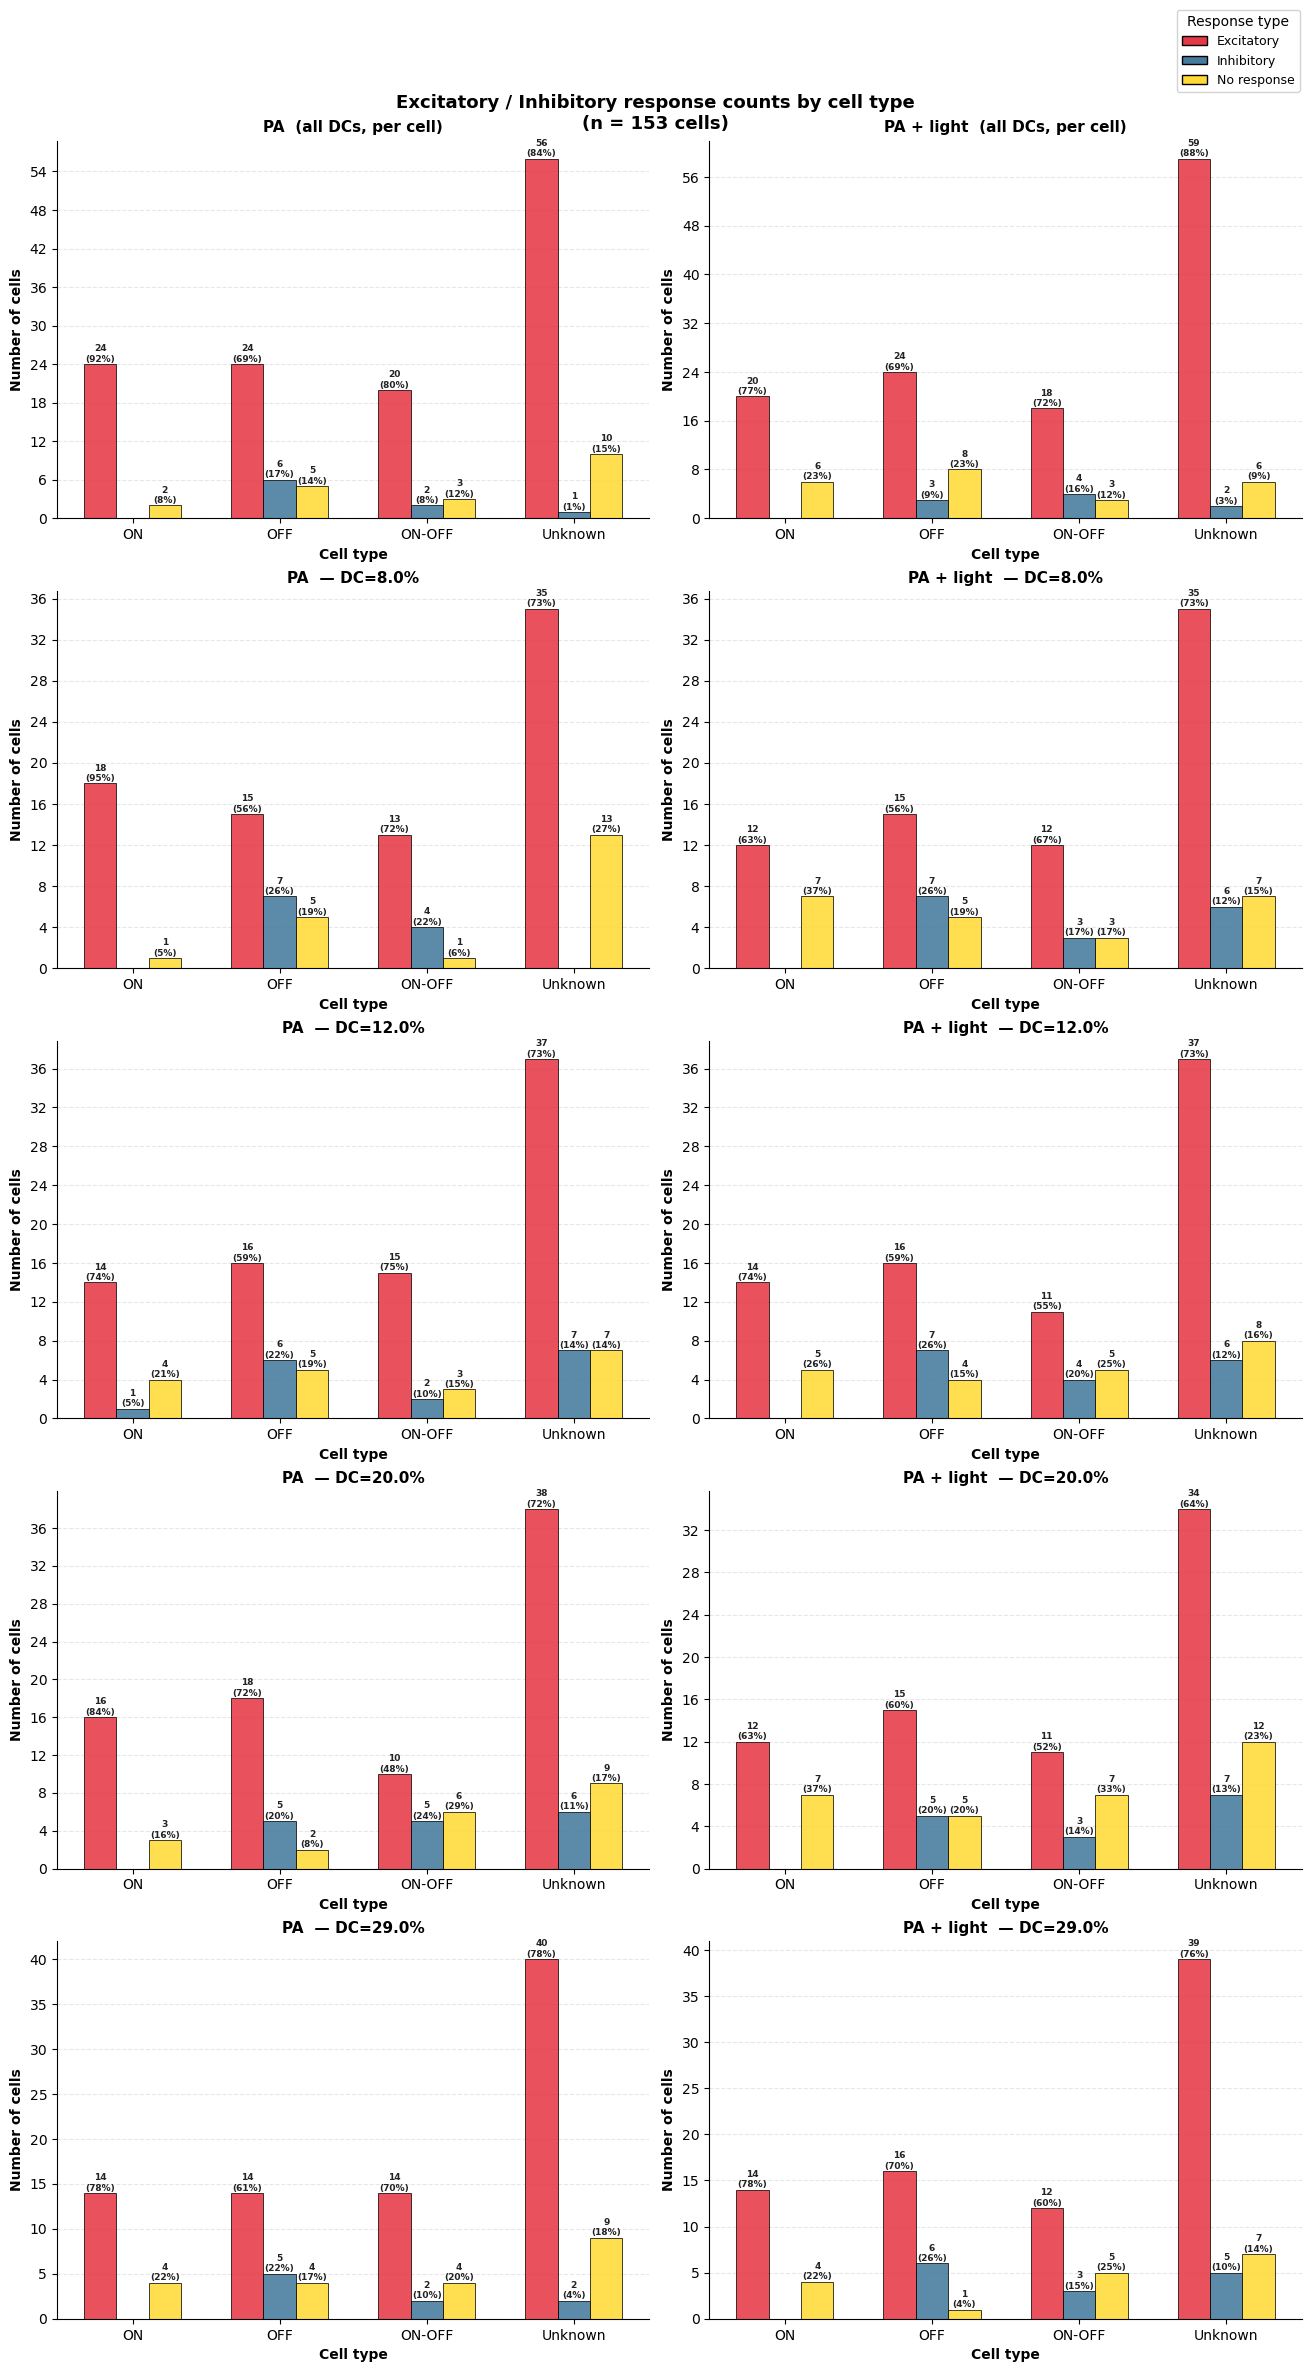

In [98]:
# ============================================================
# RESPONSE TYPE COUNT: ON / OFF / ON-OFF  ×  PA / PA+light
# ── Overall (collapsed across DCs) + per DC ────────────────
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Helpers ─────────────────────────────────────────────────────────────────

def majority_response(series):
    """Most frequent non-null string value, or None."""
    vals = [v for v in series.dropna() if isinstance(v, str)]
    return pd.Series(vals).mode()[0] if vals else None

def norm_resp(v):
    if not isinstance(v, str):
        return "No response"
    return v.capitalize()

CELL_TYPES  = ["ON", "OFF", "ON-OFF", "Unknown"]
RESP_LABELS = ["Excitatory", "Inhibitory", "No response"]
RESP_COLORS = {
    "Excitatory":  "#E63946",
    "Inhibitory":  "#457B9D",
    "No response": "#FFDA37",
}

def build_counts(df_source, per_cell=True):
    """
    Build a count + percentage table from df_merged_wide (or a DC slice).
    If per_cell=True, collapse to one row per cluster via majority vote first.
    Returns (counts_pa, counts_pl, pct_pa, pct_pl).
    """
    if per_cell:
        df = (
            df_source.reset_index()
            .groupby("cluster_id")
            .agg(
                response_type_pa=("response_type_pa", majority_response),
                response_type_pl=("response_type_pl", majority_response),
                baden_type=("baden_type", "first"),
            )
            .reset_index()
        )
    else:
        df = df_source.reset_index().copy()

    df["cell_type"] = df["baden_type"].apply(lambda bt: extract_cell_type(bt) or "Unknown")
    df["resp_pa"]   = df["response_type_pa"].apply(norm_resp)
    df["resp_pl"]   = df["response_type_pl"].apply(norm_resp)

    def pivot(resp_col):
        ct = (
            df.groupby(["cell_type", resp_col])
            .size()
            .unstack(fill_value=0)
            .reindex(index=CELL_TYPES, columns=RESP_LABELS, fill_value=0)
        )
        # Drop all-zero rows (cell types not present)
        ct = ct.loc[ct.sum(axis=1) > 0]
        pct = ct.div(ct.sum(axis=1), axis=0) * 100
        return ct, pct

    counts_pa, pct_pa = pivot("resp_pa")
    counts_pl, pct_pl = pivot("resp_pl")
    return counts_pa, counts_pl, pct_pa, pct_pl


def print_summary(label, counts_pa, counts_pl, pct_pa, pct_pl):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for stim, counts, pct in [("PA", counts_pa, pct_pa), ("PA+light", counts_pl, pct_pl)]:
        print(f"\n  [{stim}]")
        header = f"  {'Cell type':<12}" + "".join(f"{r:>16}" for r in RESP_LABELS)
        print(header)
        print("  " + "-" * (12 + 16 * len(RESP_LABELS)))
        for ct in counts.index:
            total = counts.loc[ct].sum()
            row = f"  {ct:<12}"
            for r in RESP_LABELS:
                n = int(counts.loc[ct, r])
                p = pct.loc[ct, r]
                row += f"  {n:>4} ({p:>5.1f}%)  "
            print(row + f"  [n={total}]")


def plot_grouped_bars(axes_row, counts_pa, counts_pl, pct_pa, pct_pl, title_suffix=""):
    """Fill a pair of axes with grouped bar charts (counts + % annotations)."""
    for ax, (counts, pct, stim_label) in zip(
        axes_row,
        [
            (counts_pa, pct_pa, "PA"),
            (counts_pl, pct_pl, "PA + light"),
        ],
    ):
        present_types = list(counts.index)
        n_ct   = len(present_types)
        n_resp = len(RESP_LABELS)
        x      = np.arange(n_ct)
        width  = 0.22
        offsets = np.linspace(-(n_resp - 1) / 2, (n_resp - 1) / 2, n_resp) * width

        for resp, offset in zip(RESP_LABELS, offsets):
            heights = [int(counts.loc[ct, resp]) for ct in present_types]
            pcts    = [pct.loc[ct, resp] for ct in present_types]
            bars = ax.bar(
                x + offset, heights, width,
                label=resp,
                color=RESP_COLORS[resp],
                edgecolor="k",
                linewidth=0.6,
                alpha=0.88,
            )
            for bar, h, p in zip(bars, heights, pcts):
                if h > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 0.05,
                        f"{h}\n({p:.0f}%)",
                        ha="center", va="bottom",
                        fontsize=6.5, fontweight="bold", color="#222",
                    )

        ax.set_xticks(x)
        ax.set_xticklabels(present_types, fontsize=10)
        ax.set_xlabel("Cell type", fontsize=10, fontweight="bold")
        ax.set_ylabel("Number of cells", fontsize=10, fontweight="bold")
        ax.set_title(f"{stim_label}  {title_suffix}", fontsize=11, fontweight="bold")
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)


# ── Collect DCs (drop 37) ────────────────────────────────────────────────────
dcs_all = sorted([
    dc for dc in summary_df.index.get_level_values("dc").unique()
    if dc != 37
])

# ── Overall summary ──────────────────────────────────────────────────────────
c_pa, c_pl, p_pa, p_pl = build_counts(summary_df, per_cell=True)
print_summary("OVERALL (majority vote per cell)", c_pa, c_pl, p_pa, p_pl)

# ── Per-DC summaries ─────────────────────────────────────────────────────────
dc_results = {}
for dc in dcs_all:
    df_dc = summary_df.xs(dc, level="dc", drop_level=False)
    c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc = build_counts(df_dc, per_cell=False)
    dc_results[dc] = (c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc)
    print_summary(f"DC = {dc}%", c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc)

# ── Figure layout: row 0 = overall, rows 1..N = per DC ──────────────────────
n_rows = 1 + len(dcs_all)
fig, axes = plt.subplots(
    n_rows, 2,
    figsize=(13, 4.5 * n_rows),
    constrained_layout=True,
)

# Overall row
plot_grouped_bars(axes[0], c_pa, c_pl, p_pa, p_pl, title_suffix="(all DCs, per cell)")

# Per-DC rows
for row_i, dc in enumerate(dcs_all, start=1):
    c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc = dc_results[dc]
    plot_grouped_bars(axes[row_i], c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc,
                      title_suffix=f"— DC={dc}%")

# Shared legend on the figure
handles = [
    mpatches.Patch(facecolor=RESP_COLORS[r], edgecolor="k", label=r)
    for r in RESP_LABELS
]
fig.legend(
    handles=handles,
    title="Response type",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.05),
    fontsize=9,
    title_fontsize=10,
    framealpha=0.85,
)

fig.suptitle(
    f"Excitatory / Inhibitory response counts by cell type\n"
    f"(n = {len(summary_df.index.get_level_values('cluster_id').unique())} cells)",
    fontsize=13, fontweight="bold", y=1.01,
)

plt.savefig(
    f"{figure_dir}/all_sessions_response_counts_by_cell_type_per_dc.png",
    dpi=150, bbox_inches="tight",
)
print("\n✓ Saved: response_counts_by_cell_type_per_dc.png")
plt.show()


In [ ]:
summary_df.to_csv(data_dir / f"{session_id}_summary_df.csv")

In [94]:
summary_df.head()

train_id_pa                             uid_pa  \
cluster_id       dc                                                          
uid_251014_A_001 8.0   tid_251014_A_015  uid_251014_A_001_tid_251014_A_015   
                 20.0  tid_251014_A_017  uid_251014_A_001_tid_251014_A_017   
                 29.0  tid_251014_A_018  uid_251014_A_001_tid_251014_A_018   
uid_251014_A_010 20.0  tid_251014_A_002  uid_251014_A_010_tid_251014_A_002   
uid_251014_A_014 12.0  tid_251014_A_021  uid_251014_A_014_tid_251014_A_021   

                      response_type_pa  latency_ms_pa  response_rate_pa  \
cluster_id       dc                                                       
uid_251014_A_001 8.0        excitatory          76.75          3.996941   
                 20.0       excitatory          74.75          3.051696   
                 29.0       excitatory          83.75          4.496410   
uid_251014_A_010 20.0       excitatory         155.75          0.730052   
uid_251014_A_014 12.0       excitatory         105.75          0.991662   

                       baseline_rate_pa  p_value_pa  p_bootstrap_pa  \
cluster_id       dc                                                   
uid_251014_A_001 8.0           1.250000       0.002           0.002   
                 20.0          1.750000       0.035           0.035   
                 29.0          1.250000       0.004           0.004   
uid_251014_A_010 20.0          1.634974       0.000           0.000   
uid_251014_A_014 12.0          0.999767       0.000           0.000   

                      train_id_pl uid_pl response_type_pl  latency_ms_pl  \
cluster_id       dc                                                        
uid_251014_A_001 8.0          NaN    NaN              NaN            NaN   
                 20.0         NaN    NaN              NaN            NaN   
                 29.0         NaN    NaN              NaN            NaN   
uid_251014_A_010 20.0         NaN    NaN              NaN            NaN   
uid_251014_A_014 12.0         NaN    NaN              NaN            NaN   

                       response_rate_pl  baseline_rate_pl  p_value_pl  \
cluster_id       dc                                                     
uid_251014_A_001 8.0                NaN               NaN         NaN   
                 20.0               NaN               NaN         NaN   
                 29.0               NaN               NaN         NaN   
uid_251014_A_010 20.0               NaN               NaN         NaN   
uid_251014_A_014 12.0               NaN               NaN         NaN   

                       p_bootstrap_pl                            baden_type  \
cluster_id       dc                                                           
uid_251014_A_001 8.0              NaN        {'id': 23, 'name': 'ON alpha'}   
                 20.0             NaN        {'id': 23, 'name': 'ON alpha'}   
                 29.0             NaN        {'id': 23, 'name': 'ON alpha'}   
uid_251014_A_010 20.0             NaN         {'id': 3, 'name': 'OFF slow'}   
uid_251014_A_014 12.0             NaN  {'id': None, 'name': 'Not assigned'}   

                        session  
cluster_id       dc              
uid_251014_A_001 8.0   251014_A  
                 20.0  251014_A  
                 29.0  251014_A  
uid_251014_A_010 20.0  251014_A  
uid_251014_A_014 12.0  251014_A

------------------ Test WIP ---------------

In [ ]:
baden_df_str = [df for df in summary_df.baden_type.unique()]
type_idx = []
type_name = []

for _, val in enumerate(baden_df_str):
    tmp_val = eval(val)
    type_idx.append(tmp_val['id'])
    type_name.append(tmp_val['name'])

In [98]:
summary_df.query('baden_type == @baden_df_str[1] & (response_type_pa == "excitatory" | response_type_pl =="excitatory")')

train_id_pa                             uid_pa  \
cluster_id       dc                                                          
uid_251014_A_010 20.0  tid_251014_A_002  uid_251014_A_010_tid_251014_A_002   
uid_251014_A_189 8.0   tid_251014_A_015  uid_251014_A_189_tid_251014_A_015   
uid_251014_A_250 20.0  tid_251014_A_002  uid_251014_A_250_tid_251014_A_002   
uid_251014_A_290 8.0   tid_251014_A_020  uid_251014_A_290_tid_251014_A_020   
                 12.0  tid_251014_A_021  uid_251014_A_290_tid_251014_A_021   
                 20.0  tid_251014_A_022  uid_251014_A_290_tid_251014_A_022   
uid_251014_A_296 12.0  tid_251014_A_016  uid_251014_A_296_tid_251014_A_016   
uid_251014_A_290 29.0               NaN                                NaN   
uid_251014_B_249 8.0   tid_251014_B_028  uid_251014_B_249_tid_251014_B_028   
                 12.0  tid_251014_B_029  uid_251014_B_249_tid_251014_B_029   
                 20.0  tid_251014_B_030  uid_251014_B_249_tid_251014_B_030   
                 29.0  tid_251014_B_031  uid_251014_B_249_tid_251014_B_031   

                      response_type_pa  latency_ms_pa  response_rate_pa  \
cluster_id       dc                                                       
uid_251014_A_010 20.0       excitatory         155.75          0.730052   
uid_251014_A_189 8.0        excitatory         110.25          0.126092   
uid_251014_A_250 20.0       excitatory          98.25          0.313560   
uid_251014_A_290 8.0        excitatory         103.25          1.012826   
                 12.0       excitatory         100.75          1.036575   
                 20.0       excitatory          95.75          1.033434   
uid_251014_A_296 12.0       excitatory         107.25          0.000043   
uid_251014_A_290 29.0              NaN            NaN               NaN   
uid_251014_B_249 8.0        excitatory          94.75         13.413090   
                 12.0       excitatory          67.25         22.415153   
                 20.0       excitatory          73.25         25.560998   
                 29.0       excitatory          71.25         23.547176   

                       baseline_rate_pa  p_value_pa  p_bootstrap_pa  \
cluster_id       dc                                                   
uid_251014_A_010 20.0          1.634974       0.000           0.000   
uid_251014_A_189 8.0           1.439603       0.004           0.004   
uid_251014_A_250 20.0          1.000000       0.000           0.000   
uid_251014_A_290 8.0           1.498471       0.001           0.001   
                 12.0          1.257487       0.000           0.000   
                 20.0          1.250000       0.000           0.000   
uid_251014_A_296 12.0          1.000000       0.000           0.000   
uid_251014_A_290 29.0               NaN         NaN             NaN   
uid_251014_B_249 8.0          11.249320       0.000           0.000   
                 12.0          5.250000       0.001           0.001   
                 20.0          5.220408       0.000           0.000   
                 29.0          7.762789       0.000           0.000   

                            train_id_pl                             uid_pl  \
cluster_id       dc                                                          
uid_251014_A_010 20.0               NaN                                NaN   
uid_251014_A_189 8.0                NaN                                NaN   
uid_251014_A_250 20.0               NaN                                NaN   
uid_251014_A_290 8.0   tid_251014_A_035  uid_251014_A_290_tid_251014_A_035   
                 12.0  tid_251014_A_041  uid_251014_A_290_tid_251014_A_041   
                 20.0  tid_251014_A_047  uid_251014_A_290_tid_251014_A_047   
uid_251014_A_296 12.0  tid_251014_A_040  uid_251014_A_296_tid_251014_A_040   
uid_251014_A_290 29.0  tid_251014_A_053  uid_251014_A_290_tid_251014_A_053   
uid_251014_B_249 8.0   tid_251014_B_063  uid_251014_B_249_tid_251014_B_063   
                 12.0  tid_2510

In [131]:
dcs_all = sorted([int(dc) for dc in summary_df.index.get_level_values("dc").unique() if dc != 37])
exc_cells = [f'nb_exc_cell_dc{dc:02d}' for dc in dcs_all]
inh_cells = [f'nb_inh_cell_dc{dc:02d}' for dc in dcs_all]

In [224]:
baden_ids = []
baden_names = []

for _, val in enumerate(baden_df_str):
    tmp_val = eval(val)
    for i in range(len(dcs_all)):
        baden_ids.append(tmp_val['id'])
        baden_names.append(tmp_val['name'])
df_by_type = pd.DataFrame({'baden_id': baden_ids,
                                'baden_name': baden_names,
                                'dc': dcs_all*len(type_idx),})
# df_by_type.set_index(['baden_id', 'baden_name'], inplace=True)
df_by_type.set_index(['baden_name','dc'], inplace=True)


nb_exc_cell_by_type = [0 for i in range(len(df_by_type))]
nb_inh_cell_by_type = [0 for i in range(len(df_by_type))]

for i, dc in enumerate(dcs_all):
    sub_df = summary_df.xs(dc, level="dc")

    if sub_df.empty:
        continue
    
    for j, type in enumerate(baden_df_str):
        val_exc = len(sub_df.query(
            'baden_type == @type & (response_type_pa == "excitatory" | response_type_pl == "excitatory")'))
        val_inh = len(sub_df.query(
            'baden_type == @type & (response_type_pa == "inhibitory" | response_type_pl == "inhibitory")'))
        nb_exc_cell_by_type[i + 4*j] = val_exc
        nb_inh_cell_by_type[i + 4*j] = val_inh
    
df_by_type.insert(loc = len(df_by_type.columns),
                            column = 'exc_cells',
                            value = nb_exc_cell_by_type)
df_by_type.insert(loc = len(df_by_type.columns),
                            column = 'inh_cells',
                            value = nb_inh_cell_by_type)
df_by_type

baden_id  exc_cells  inh_cells
baden_name        dc                                
ON alpha          8       23.0          1          0
                  12      23.0          1          0
                  20      23.0          2          0
                  29      23.0          2          0
OFF slow          8        3.0          3          0
...                        ...        ...        ...
ON-OFF JAM-B      29       5.0          2          3
ON high frequency 8       19.0          1          0
                  12      19.0          1          0
                  20      19.0          1          0
                  29      19.0          1          0

[72 rows x 3 columns]

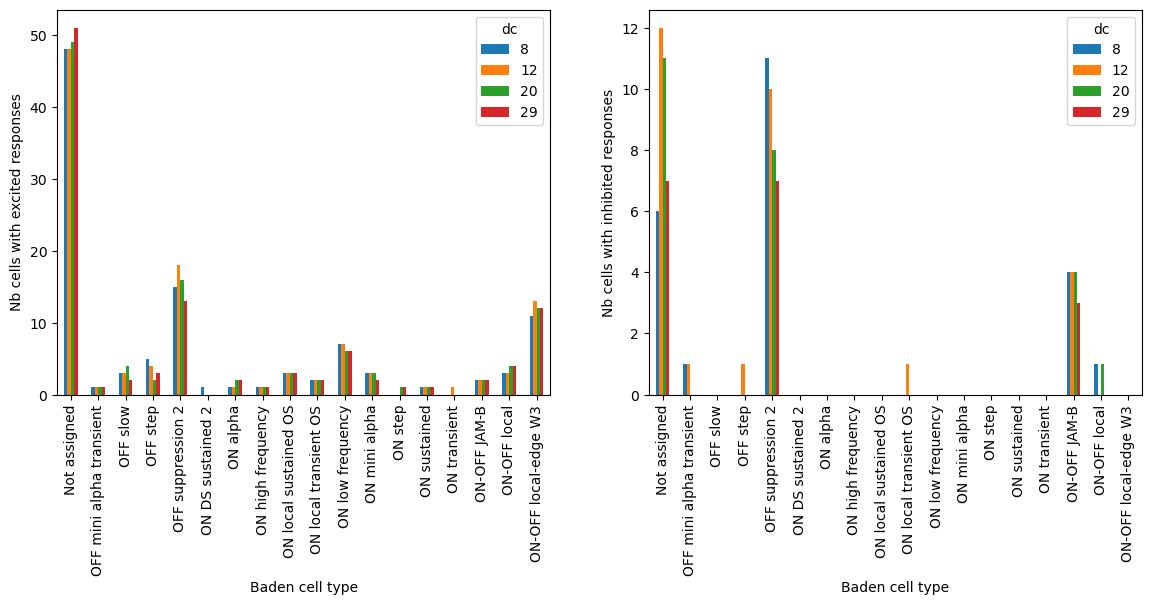

In [225]:
df_by_type_notstacked = df_by_type.unstack()

fig, (ax_exc, ax_inh) = plt.subplots(ncols=2, figsize=(14, 5))

df_by_type_notstacked['exc_cells'].plot(kind = "bar", ax=ax_exc)
ax_exc.set_ylabel("Nb cells with excited responses")
ax_exc.set_xlabel("Baden cell type")

df_by_type_notstacked['inh_cells'].plot(kind = "bar", ax=ax_inh)
ax_inh.set_ylabel("Nb cells with inhibited responses")
ax_inh.set_xlabel("Baden cell type")

plt.savefig(figure_dir/"response_per_cell_type.png", bbox_inches='tight')